In [1]:
import numpy as np
import matplotlib.pyplot as plt

original_game = dict([
    (1, 38),
    (4, 14),
    (9, 31),
    (16, 6),
    (21, 42),
    (28, 84),
    (36, 44),
    (47, 36),
    (49, 11),
    (51, 67),
    (56, 53),
    (62, 19),
    (64, 60),
    (71, 91),
    (80, 100),
    (87, 24),
    (93, 73),
    (95, 75),
    (98, 78)
])

In [10]:
def snakes_and_ladders(
    board_size: int = 100,
    board: dict = None,
    die_size : int = 6,
    visualize: bool = False,
    exact: bool = True
) -> float:
    """
    Computes the expected length of a Snakes and Ladders game.
    
    Parameters:
    - board_size: Size of the game board.
    - board: Dictionary representing snakes and ladders.
    - die_size: Number of faces on the die.
    - visualize: Whether to visualize the transition matrix.
    - exact: Determines if player needs to land exactly on the last square.
    
    Returns:
    - expected_steps: Expected number of moves to finish the game.
    """
    # establish defaults
    N = board_size
    if board is None:
        board = dict()
        
    m = np.zeros(shape=(N+1, N+1))
    
    for i in range(N):
        for roll in range(1, die_size+1):
            j = i + roll
    
            if exact:
                # must end exactly on the final square,
                # or bounce otherwise
                if j > N:
                    j = N - (j - N)
            else:
                # any move after the final square ends the game
                if j > N:
                    j = N
    
            # follow chutes/ladders if we land on them.
            j = board.get(j, j)
    
            # it's possible to have two different paths
            # to the same square, so we increment by one
            # instead of setting it equal to one.
            m[i, j] += 1
    
    # set the final state, 100, to be an absorbing state
    # to represent game over.
    m[N, N] = 1
    
    # normalize the matrix to a right stochastic matrix
    # where all rows sum to 1.
    m /= m.sum(axis=1, keepdims=True)

    # visualize the transition matrix
    if visualize: 
        plt.figure(figsize=(8, 8))
        plt.pcolormesh(m, edgecolors='k', linewidth=0.5)
        ax = plt.gca()
        ax.set_aspect('equal')

    # Calculate the fundamental matrix and invert
    # to obtain the expected number of steps to transition
    # to the absorbing state
    Q = m[:-1, :-1]
    expected_steps_matrix = np.linalg.inv(np.eye(Q.shape[0]) - Q)
    
    # The expected number of steps from state 1 to the absorbing state
    expected_steps = expected_steps_matrix[0].sum()
    
    return expected_steps

43.68510050013852

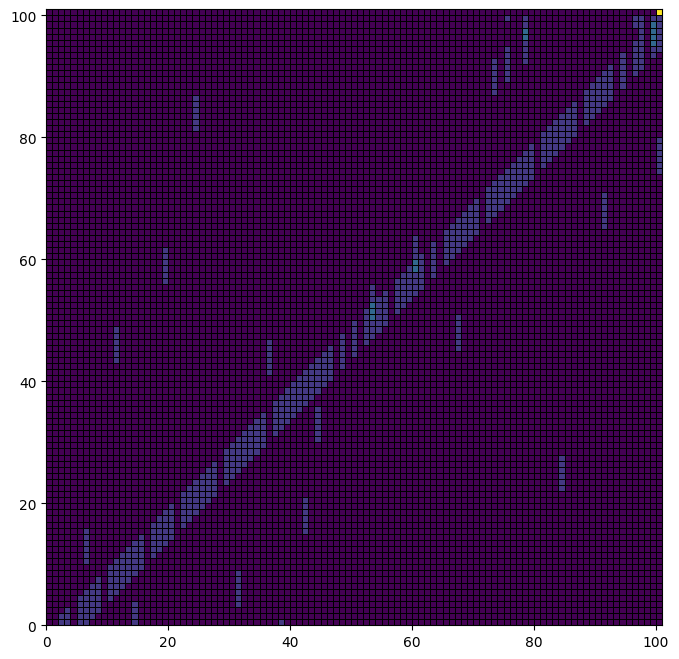

In [11]:
snakes_and_ladders(100, original_game, visualize=True)

36.30778034624256

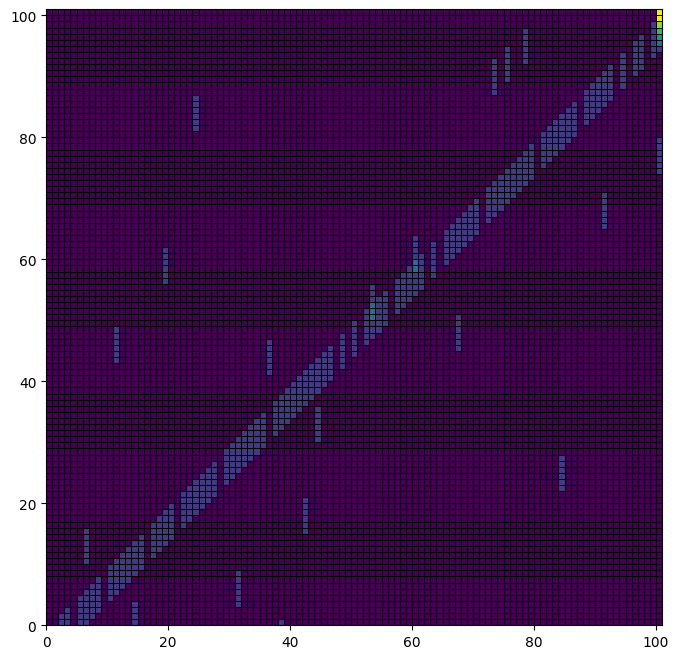

In [12]:
snakes_and_ladders(100, original_game, visualize=True, exact=False)

In [13]:
snakes_and_ladders(100, original_game)

43.68510050013852

In [27]:
def game_variants(N, game, max_delta=2):
    for key in game:
        value = game[key]
        for delta in range(-max_delta, max_delta+1):
            new_value = value + delta
            if new_value <= N and new_value >= 1:
                variant = game.copy()
                variant[key] = new_value
                yield key, delta, variant

variant_results = []
for key, delta, variant in game_variants(100, original_game):
    result = snakes_and_ladders(100, variant)
    error = (result - 42)**2
    variant_results.append( (error, result, key, delta) )

sorted(variant_results)[:5]

[(0.004981878376348339, 42.07058242257353, 93, 1),
 (0.4196230937903579, 42.64778321511935, 36, 2),
 (0.45598218231584153, 42.67526452765997, 64, 2),
 (0.48335296697089125, 42.69523590742344, 93, 2),
 (0.629936116753641, 42.79368514963658, 36, 1)]

In [28]:
hitchhikers_game = dict([
    (1, 38),
    (4, 14),
    (9, 31),
    (16, 6),
    (21, 42),
    (28, 84),
    (36, 44),
    (47, 36),
    (49, 11),
    (51, 67),
    (56, 53),
    (62, 19),
    (64, 60),
    (71, 91),
    (80, 100),
    (87, 24),
    (93, 74),
    (95, 75),
    (98, 78)
])

In [29]:
snakes_and_ladders(100, hitchhikers_game)

42.07058242257353

In [30]:
variant_results = []
for key, delta, variant in game_variants(100, hitchhikers_game):
    result = snakes_and_ladders(100, variant)
    error = (result - 42)**2
    variant_results.append( (error, result, key, delta) )

sorted(variant_results)[:5]

[(4.7001428837577326e-05, 41.9931442411917, 21, 2),
 (0.00017393091830435198, 41.9868117128366, 1, 1),
 (0.000404278963891651, 42.02010668953089, 9, 1),
 (0.0018614160037459645, 41.9568558694172, 9, 2),
 (0.0019818827188736693, 42.04451834137604, 47, -1)]

In [31]:
ultimate_game = dict([
    (1, 38),
    (4, 14),
    (9, 31),
    (16, 6),
    (21, 44),
    (28, 84),
    (36, 44),
    (47, 36),
    (49, 11),
    (51, 67),
    (56, 53),
    (62, 19),
    (64, 60),
    (71, 91),
    (80, 100),
    (87, 24),
    (93, 74),
    (95, 75),
    (98, 78)
])

In [32]:
snakes_and_ladders(100, ultimate_game)

41.9931442411917